# Laba 5 Variant 7

In [10]:
import numpy as np

A = np.array([
    [ 39, -4, -5, -9, -1],
    [  5, 39, -9,  3,  7],
    [  7,  8, 33, -5, -9],
    [  2,  3,  8, 43,  9],
    [-10,  5,  2,  0, 38]
], dtype=float)

b = np.array([20, 45, 34, 65, 35], dtype=float)


def jacobi(A, b, x0=None, eps=1e-8, max_iter=10000):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    n = len(b)
    if x0 is None:
        x = np.zeros(n)
    else:
        x = np.array(x0, dtype=float).copy()

    D = np.diag(A)
    R = A - np.diagflat(D)

    for k in range(1, max_iter + 1):
        x_new = (b - R @ x) / D

        if np.linalg.norm(x_new - x, ord=np.inf) < eps:
            return x_new, k

        x = x_new

    return x, max_iter


def seidel(A, b, x0=None, eps=1e-8, max_iter=10000):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    n = len(b)
    if x0 is None:
        x = np.zeros(n)
    else:
        x = np.array(x0, dtype=float).copy()

    for k in range(1, max_iter + 1):
        x_old = x.copy()

        for i in range(n):
            s1 = A[i, :i] @ x[:i]         
            s2 = A[i, i+1:] @ x_old[i+1:]
            x[i] = (b[i] - s1 - s2) / A[i, i]

        if np.linalg.norm(x - x_old, ord=np.inf) < eps:
            return x, k

    return x, max_iter


eps = 1e-8

x_j, it_j = jacobi(A, b, eps=eps)
x_gs, it_gs = seidel(A, b, eps=eps)

print("Метод Якоби:")
print("x =", x_j)
print("||Ax-b||_2 =", np.linalg.norm(A @ x_j - b))

print("\nМетод Зейделя:")
print("x =", x_gs)
print("||Ax-b||_2 =", np.linalg.norm(A @ x_gs - b))



Метод Якоби:
x = [1. 1. 1. 1. 1.]
||Ax-b||_2 = 1.537093167574612e-07

Метод Зейделя:
x = [1. 1. 1. 1. 1.]
||Ax-b||_2 = 3.662139181252432e-08


# Laba 7

In [12]:
import numpy as np

A = np.array([
    [ 39, -4, -5, -9, -1],
    [  5, 39, -9,  3,  7],
    [  7,  8, 33, -5, -9],
    [  2,  3,  8, 43,  9],
    [-10,  5,  2,  0, 38]
], dtype=float)

b = np.array([20, 45, 34, 65, 35], dtype=float)

x_exact = np.ones(5)

def iteration(A, b, x0=None, eps=1e-10, max_iter=10000):
    n = len(b)
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()

    D = np.diag(A)
    R = A - np.diagflat(D)  # L + U

    for k in range(1, max_iter + 1):
        x_new = (b - R @ x) / D
        if np.linalg.norm(x_new - x, ord=np.inf) < eps:
            return x_new, k
        x = x_new

    return x, max_iter


# ===== 2) Метод верхней релаксации (SOR) =====
def sor(A, b, omega=1.0, x0=None, eps=1e-10, max_iter=10000):
    n = len(b)
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()

    for k in range(1, max_iter + 1):
        x_old = x.copy()

        for i in range(n):
            s1 = A[i, :i] @ x[:i]             # уже обновлённые x
            s2 = A[i, i+1:] @ x_old[i+1:]     # старые x
            x[i] = (1 - omega) * x_old[i] + (omega / A[i, i]) * (b[i] - s1 - s2)

        if np.linalg.norm(x - x_old, ord=np.inf) < eps:
            return x, k

    return x, max_iter


# ===== Запуск =====
eps = 1e-12

x_j, it_j = iteration(A, b, eps=eps)
x_s, it_s = sor(A, b, omega=1.2, eps=eps)   # ω>1 — верхняя релаксация

def report(name, x, it):
    r = A @ x - b
    print(f"\n{name}")
    print("x =", x)
    print("ocation =", it)
    print("||Ax-b||_inf =", np.linalg.norm(r, ord=np.inf))
    print("||x-x_exact||_inf =", np.linalg.norm(x - x_exact, ord=np.inf))

report("Якоби (простая итерация)", x_j, it_j)
report("SOR (верхняя релаксация), ω=1.2", x_s, it_s)

print("\nТочное решение:", x_exact)



Якоби (простая итерация)
x = [1. 1. 1. 1. 1.]
ocation = 28
||Ax-b||_inf = 7.51754214434186e-12
||x-x_exact||_inf = 2.604583215770617e-13

SOR (верхняя релаксация), ω=1.2
x = [1. 1. 1. 1. 1.]
ocation = 33
||Ax-b||_inf = 5.6701310313655995e-12
||x-x_exact||_inf = 1.8984813721090177e-13

Точное решение: [1. 1. 1. 1. 1.]


# Laba 6

Точное решение: [1. 1. 1. 1. 1.]

1) Минимальных невязок: x = [1. 1. 1. 1. 1.] ||x-x*|| = 6.703136525521967e-13 итераций = 24
2) Скорейшего спуска:  x = [1. 1. 1. 1. 1.] ||x-x*|| = 9.195533977080915e-13 итераций = 24
3) Минимальных поправок: x = [1. 1. 1. 1. 1.] ||x-x*|| = 1.3776528827457654e-12 итераций = 25
4) Сопряженных градиентов (норм. ур.): x = [1. 1. 1. 1. 1.] ||x-x*|| = 2.7194799110210365e-16 итераций = 5


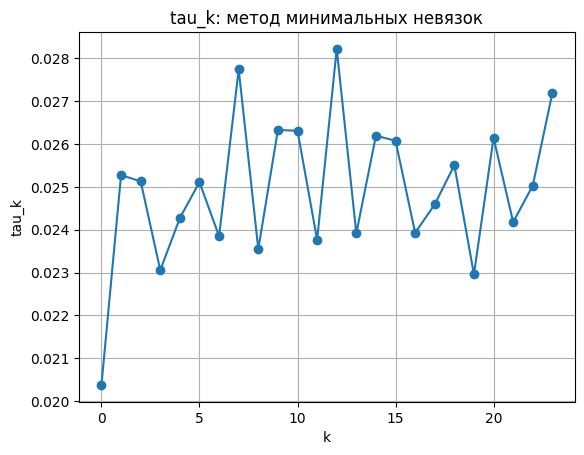

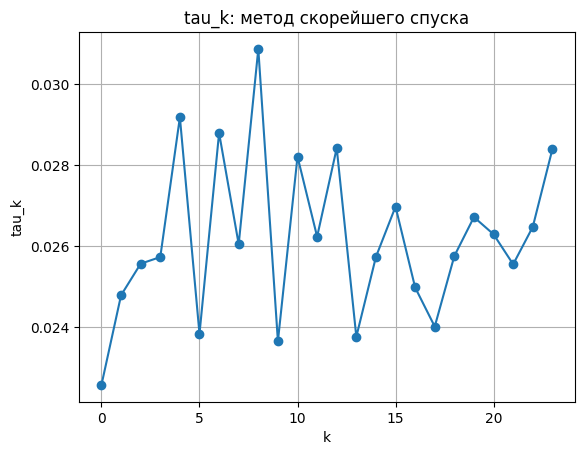

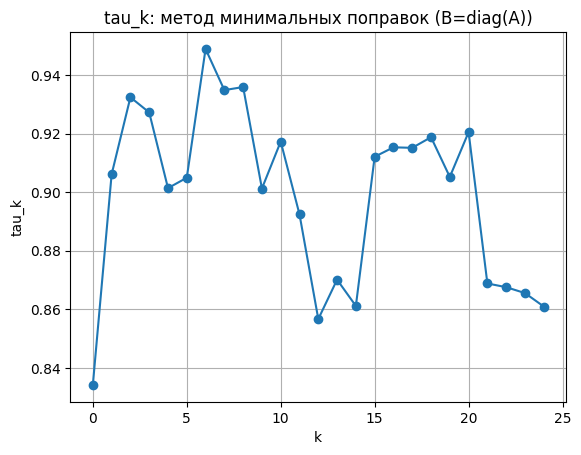

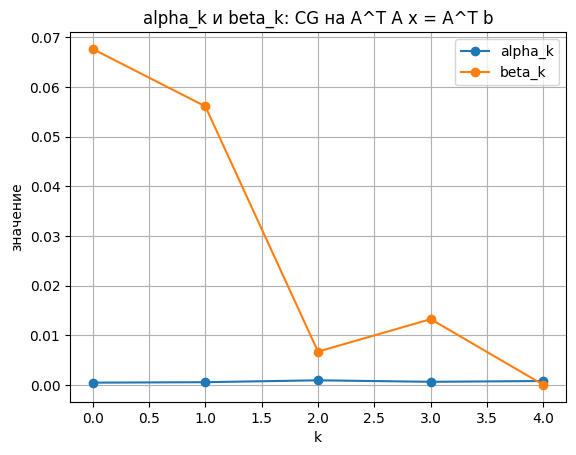

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ====== Данные (вариант 7) ======
A = np.array([
    [ 39, -4, -5, -9, -1],
    [  5, 39, -9,  3,  7],
    [  7,  8, 33, -5, -9],
    [  2,  3,  8, 43,  9],
    [-10,  5,  2,  0, 38]
], dtype=float)

b = np.array([20, 45, 34, 65, 35], dtype=float)
x_true = np.ones(5)

# ====== 1) Метод минимальных невязок ======
# r_k = A x_k - b
# tau_k = (A r_k, r_k) / (A r_k, A r_k)
# x_{k+1} = x_k - tau_k r_k
def minimal_residuals(A, b, x0=None, tol=1e-12, max_iter=2000):
    n = b.size
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()
    taus, res = [], []
    bn = np.linalg.norm(b)

    for k in range(max_iter):
        r = A @ x - b
        rn = np.linalg.norm(r)
        res.append(rn)
        if rn / bn < tol:
            break

        Ar = A @ r
        tau = float((Ar @ r) / (Ar @ Ar))
        taus.append(tau)
        x = x - tau * r

    return x, np.array(taus), np.array(res)

# ====== 2) Метод скорейшего спуска ======
# r_k = b - A x_k
# tau_k = (r_k, r_k) / (r_k, A r_k)
# x_{k+1} = x_k + tau_k r_k
def steepest_descent(A, b, x0=None, tol=1e-12, max_iter=2000):
    n = b.size
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()
    taus, res = [], []
    bn = np.linalg.norm(b)

    for k in range(max_iter):
        r = b - A @ x
        rn = np.linalg.norm(r)
        res.append(rn)
        if rn / bn < tol:
            break

        Ar = A @ r
        denom = float(r @ Ar)
        tau = float((r @ r) / denom)
        taus.append(tau)
        x = x + tau * r

    return x, np.array(taus), np.array(res)

# ====== 3) Метод минимальных поправок (с предобусловливанием B = diag(A)) ======
# r_k = A x_k - b
# omega_k = B^{-1} r_k
# tau_k = (A omega_k, omega_k) / (B^{-1} A omega_k, A omega_k)
# x_{k+1} = x_k - tau_k omega_k
def minimal_corrections(A, b, x0=None, tol=1e-12, max_iter=2000):
    n = b.size
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()
    diag = np.diag(A).copy()
    taus, res = [], []
    bn = np.linalg.norm(b)

    for k in range(max_iter):
        r = A @ x - b
        rn = np.linalg.norm(r)
        res.append(rn)
        if rn / bn < tol:
            break

        omega = r / diag          # B^{-1} r
        Aomega = A @ omega
        v = Aomega / diag         # B^{-1} A omega

        tau = float((Aomega @ omega) / (v @ Aomega))
        taus.append(tau)
        x = x - tau * omega

    return x, np.array(taus), np.array(res)

# ====== 4) Метод сопряженных градиентов на нормальных уравнениях (A^T A x = A^T b) ======
def cg_normal_equations(A, b, x0=None, tol=1e-12, max_iter=2000):
    AtA = A.T @ A
    Atb = A.T @ b

    n = b.size
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()

    r = Atb - AtA @ x
    p = r.copy()

    alphas, betas, res = [], [], []
    bn = np.linalg.norm(Atb)

    rr = float(r @ r)
    for k in range(max_iter):
        res.append(np.sqrt(rr))
        if np.sqrt(rr) / bn < tol:
            break

        Ap = AtA @ p
        alpha = rr / float(p @ Ap)
        alphas.append(alpha)

        x = x + alpha * p
        r_new = r - alpha * Ap

        rr_new = float(r_new @ r_new)
        beta = rr_new / rr
        betas.append(beta)

        p = r_new + beta * p
        r = r_new
        rr = rr_new

    return x, np.array(alphas), np.array(betas), np.array(res)

# ====== Запуск ======
x_mr, tau_mr, res_mr = minimal_residuals(A, b)
x_sd, tau_sd, res_sd = steepest_descent(A, b)
x_mc, tau_mc, res_mc = minimal_corrections(A, b)
x_cg, alpha_cg, beta_cg, res_cg = cg_normal_equations(A, b)

print("Точное решение:", x_true)
print("\n1) Минимальных невязок: x =", x_mr, "||x-x*|| =", np.linalg.norm(x_mr - x_true), "итераций =", len(tau_mr))
print("2) Скорейшего спуска:  x =", x_sd, "||x-x*|| =", np.linalg.norm(x_sd - x_true), "итераций =", len(tau_sd))
print("3) Минимальных поправок: x =", x_mc, "||x-x*|| =", np.linalg.norm(x_mc - x_true), "итераций =", len(tau_mc))
print("4) Сопряженных градиентов (норм. ур.): x =", x_cg, "||x-x*|| =", np.linalg.norm(x_cg - x_true), "итераций =", len(alpha_cg))

# ====== Показ изменения итерационных параметров ======
plt.figure()
plt.plot(tau_mr, marker='o')
plt.title("tau_k: метод минимальных невязок")
plt.xlabel("k")
plt.ylabel("tau_k")
plt.grid(True)

plt.figure()
plt.plot(tau_sd, marker='o')
plt.title("tau_k: метод скорейшего спуска")
plt.xlabel("k")
plt.ylabel("tau_k")
plt.grid(True)

plt.figure()
plt.plot(tau_mc, marker='o')
plt.title("tau_k: метод минимальных поправок (B=diag(A))")
plt.xlabel("k")
plt.ylabel("tau_k")
plt.grid(True)

plt.figure()
plt.plot(alpha_cg, marker='o', label='alpha_k')
plt.plot(beta_cg, marker='o', label='beta_k')
plt.title("alpha_k и beta_k: CG на A^T A x = A^T b")
plt.xlabel("k")
plt.ylabel("значение")
plt.grid(True)
plt.legend()

plt.show()


# Laba 9

In [ ]:
import numpy as np

A = np.array([
    [35,  3,  6,  0, -8],
    [ 3, 38,  6, -5,  0],
    [ 6,  6, 42, -4, -7],
    [ 0, -5, -4, 38,  4],
    [-8,  0, -7,  4, 48]
], dtype=float)

b = np.array([36, 42, 43, 33, 37], dtype=float)  # в этой лабе не нужен, оставил для полноты


# 1) Метод РМ-разложения (QR-итерации): A_k = R_k M_k, A_{k+1} = M_k R_k
def rm_qr_max_eig(A, tol=1e-12, max_iter=10000):
    Ak = A.copy()
    for it in range(1, max_iter + 1):
        R, M = np.linalg.qr(Ak)      # R — ортогональная, M — верхнетреугольная (обычно пишут Q,R)
        Ak1 = M @ R                  # A_{k+1} = M_k R_k

        off = Ak1 - np.diag(np.diag(Ak1))
        if np.linalg.norm(off, ord="fro") < tol:
            Ak = Ak1
            break
        Ak = Ak1

    diag = np.diag(Ak)
    return float(np.max(diag)), it, diag


# 2) Метод скалярных произведений (степенной метод + оценка λ по скалярным произведениям)
def scalar_products_max_eig(A, x0=None, tol=1e-12, max_iter=10000):
    n = A.shape[0]
    x = np.ones(n) if x0 is None else np.array(x0, dtype=float)
    x /= np.linalg.norm(x)

    lam_old = 0.0
    for it in range(1, max_iter + 1):
        y = A @ x
        lam = float(np.dot(y, x) / np.dot(x, x))  # (Ax, x) / (x, x)
        x = y / np.linalg.norm(y)

        if abs(lam - lam_old) < tol * max(1.0, abs(lam)):
            return lam, it, x
        lam_old = lam

    return lam, it, x


# Проверка через np.linalg.eig(A)
eigvals = np.linalg.eig(A)[0]
lam_true = float(np.max(eigvals.real))

lam_rm, it_rm, diag_rm = rm_qr_max_eig(A)
lam_sp, it_sp, vec_sp = scalar_products_max_eig(A)

print("Проверка np.linalg.eig(A):        ", lam_true)
print("Метод РМ-разложения (QR):         ", lam_rm, " итераций:", it_rm)
print("Метод скалярных произведений:     ", lam_sp, " итераций:", it_sp)

# Если нужно посмотреть, к чему сошлась диагональ в QR-итерациях:
print("Диагональ после QR-итераций:", diag_rm)


# Laba 10

In [ ]:
import numpy as np

# ===== Данные варианта №7 =====
# 2x1 - x2 = 1
# 3x1 + 6x2 - 2x3 = 9
# x2 - 5x3 + 2x4 = 3
# 4x3 - 7x4 + x5 = -6
# x4 + 5x5 + 2x6 = 8
# -2x5 + 7x6 = 5

# a[i] * x_{i-1} + b[i] * x_i + c[i] * x_{i+1} = d[i]
a = np.array([0, 3, 1, 4, 1, -2], dtype=float)   # поддиагональ (a[0]=0)
b = np.array([2, 6, -5, -7, 5, 7], dtype=float)  # диагональ
c = np.array([-1, -2, 2, 1, 2, 0], dtype=float)  # наддиагональ (c[n-1]=0)
d = np.array([1, 9, 3, -6, 8, 5], dtype=float)   # правая часть


def right_sweep(a, b, c, d):
    """Правая прогонка (слева направо): x[i] = alpha[i]*x[i+1] + beta[i]"""
    n = len(b)
    alpha = np.zeros(n, dtype=float)
    beta = np.zeros(n, dtype=float)

    denom = b[0]
    if abs(denom) < 1e-15:
        raise ZeroDivisionError("Нулевой знаменатель на шаге 0 (правая прогонка).")

    alpha[0] = -c[0] / denom
    beta[0] = d[0] / denom

    for i in range(1, n):
        denom = b[i] + a[i] * alpha[i - 1]
        if abs(denom) < 1e-15:
            raise ZeroDivisionError(f"Нулевой знаменатель на шаге {i} (правая прогонка).")

        alpha[i] = (-c[i] / denom) if i != n - 1 else 0.0
        beta[i] = (d[i] - a[i] * beta[i - 1]) / denom

    x = np.zeros(n, dtype=float)
    x[-1] = beta[-1]
    for i in range(n - 2, -1, -1):
        x[i] = alpha[i] * x[i + 1] + beta[i]
    return x


def left_sweep(a, b, c, d):
    """
    Левая прогонка (справа налево):
    строим x[i] = p[i]*x[i-1] + q[i], затем восстанавливаем слева направо
    """
    n = len(b)
    p = np.zeros(n, dtype=float)
    q = np.zeros(n, dtype=float)

    # старт с последнего уравнения: a[n-1] x[n-2] + b[n-1] x[n-1] = d[n-1]
    denom = b[-1]
    if abs(denom) < 1e-15:
        raise ZeroDivisionError("Нулевой знаменатель на последнем шаге (левая прогонка).")

    p[-1] = -a[-1] / denom
    q[-1] = d[-1] / denom

    for i in range(n - 2, -1, -1):
        denom = b[i] + c[i] * p[i + 1]
        if abs(denom) < 1e-15:
            raise ZeroDivisionError(f"Нулевой знаменатель на шаге {i} (левая прогонка).")

        p[i] = (-a[i] / denom) if i != 0 else 0.0  # a[0]=0, можно не трогать
        q[i] = (d[i] - c[i] * q[i + 1]) / denom

    # найдём x0 из первого уравнения: b0*x0 + c0*x1 = d0, а x1 = p1*x0 + q1
    denom0 = b[0] + c[0] * p[1]
    if abs(denom0) < 1e-15:
        raise ZeroDivisionError("Нулевой знаменатель при нахождении x0 (левая прогонка).")

    x = np.zeros(n, dtype=float)
    x[0] = (d[0] - c[0] * q[1]) / denom0

    for i in range(1, n):
        x[i] = p[i] * x[i - 1] + q[i]
    return x


def meeting_sweep(a, b, c, d, k=None):
    """
    Встречная прогонка:
    слева строим x[i]=A[i]*x[i+1]+B[i] до k,
    справа строим x[i]=P[i]*x[i-1]+Q[i] до k+1,
    затем "стыкуем" в точке (k, k+1).
    """
    n = len(b)
    if k is None:
        k = n // 2 - 1   # для n=6 => k=2 (стык между x3 и x4 в 1-индексации)

    # Левая часть (как правая прогонка) до k
    A = np.zeros(n, dtype=float)
    B = np.zeros(n, dtype=float)

    denom = b[0]
    if abs(denom) < 1e-15:
        raise ZeroDivisionError("Нулевой знаменатель на шаге 0 (встречная, левая часть).")

    A[0] = -c[0] / denom
    B[0] = d[0] / denom

    for i in range(1, k + 1):
        denom = b[i] + a[i] * A[i - 1]
        if abs(denom) < 1e-15:
            raise ZeroDivisionError(f"Нулевой знаменатель на шаге {i} (встречная, левая часть).")
        A[i] = -c[i] / denom
        B[i] = (d[i] - a[i] * B[i - 1]) / denom

    # Правая часть (как левая прогонка) от конца до k+1
    P = np.zeros(n, dtype=float)
    Q = np.zeros(n, dtype=float)

    denom = b[-1]
    if abs(denom) < 1e-15:
        raise ZeroDivisionError("Нулевой знаменатель на последнем шаге (встречная, правая часть).")

    P[-1] = -a[-1] / denom
    Q[-1] = d[-1] / denom

    for i in range(n - 2, k, -1):  # i = n-2 ... k+1
        denom = b[i] + c[i] * P[i + 1]
        if abs(denom) < 1e-15:
            raise ZeroDivisionError(f"Нулевой знаменатель на шаге {i} (встречная, правая часть).")
        P[i] = -a[i] / denom
        Q[i] = (d[i] - c[i] * Q[i + 1]) / denom

    # Стыковка:
    # x[k]   = A[k]*x[k+1] + B[k]
    # x[k+1] = P[k+1]*x[k] + Q[k+1]
    denom_join = 1.0 - A[k] * P[k + 1]
    if abs(denom_join) < 1e-15:
        raise ZeroDivisionError("Нулевой знаменатель при стыковке (встречная прогонка).")

    x = np.zeros(n, dtype=float)
    x[k] = (A[k] * Q[k + 1] + B[k]) / denom_join
    x[k + 1] = P[k + 1] * x[k] + Q[k + 1]

    # Восстановление слева
    for i in range(k - 1, -1, -1):
        x[i] = A[i] * x[i + 1] + B[i]

    # Восстановление справа
    for i in range(k + 2, n):
        x[i] = P[i] * x[i - 1] + Q[i]

    return x


# ===== Запуск всех трёх методов =====
x_right = right_sweep(a, b, c, d)
x_left = left_sweep(a, b, c, d)
x_meet = meeting_sweep(a, b, c, d)

print("Правая прогонка  :", x_right)
print("Левая прогонка   :", x_left)
print("Встречная прогонка:", x_meet)

# Проверка (невязка)
def residual(a, b, c, x, d):
    n = len(x)
    r = np.zeros(n)
    for i in range(n):
        s = b[i] * x[i]
        if i > 0:   s += a[i] * x[i - 1]
        if i < n-1: s += c[i] * x[i + 1]
        r[i] = s - d[i]
    return r

print("Невязка (правая) :", residual(a, b, c, x_right, d))
print("Ожидаемо: x = [1, 1, 0, 1, 1, 1]")
    

# Laba 4

In [ ]:
import numpy as np

def make_diagonally_dominant(n, low=-5, high=5, seed=0):
    """
    Генерирует матрицу A (n×n) с диагональным преобладанием и вектор b так,
    чтобы у системы было известное точное решение x_true.
    """
    rng = np.random.default_rng(seed)
    A = rng.integers(low, high + 1, size=(n, n)).astype(float)

    # усиливаем диагональ: |a_ii| > sum_{j!=i} |a_ij|
    for i in range(n):
        A[i, i] = 0.0
        s = np.sum(np.abs(A[i]))
        A[i, i] = s + rng.uniform(1.0, 5.0)  # строго больше суммы внедиагональных

    x_true = rng.uniform(-2, 2, size=n)
    b = A @ x_true
    return A, b, x_true

def gauss_seidel(A, b, x0=None, tol=1e-10, max_iter=10000):
    """
    Метод Гаусса-Зейделя: решает Ax=b итерационно.
    Возвращает (x, iterations, residual_norm).
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    n = A.shape[0]
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()

    # проверка нулей на диагонали (для метода нельзя)
    if np.any(np.isclose(np.diag(A), 0.0)):
        raise ValueError("На диагонали есть нули — метод Гаусса-Зейделя неприменим без перестановок строк.")

    for it in range(1, max_iter + 1):
        x_old = x.copy()

        for i in range(n):
            # sum_{j<i} a_ij x_j (уже обновленные) + sum_{j>i} a_ij x_old_j
            s1 = A[i, :i] @ x[:i]
            s2 = A[i, i+1:] @ x_old[i+1:]
            x[i] = (b[i] - s1 - s2) / A[i, i]

        # критерий остановки (по изменению решения)
        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            r = b - A @ x
            return x, it, np.linalg.norm(r, ord=np.inf)

    r = b - A @ x
    return x, max_iter, np.linalg.norm(r, ord=np.inf)

def demo(n, seed=0):
    A, b, x_true = make_diagonally_dominant(n, seed=seed)
    x_gs, iters, rnorm = gauss_seidel(A, b, tol=1e-12, max_iter=20000)

    # для контроля — точное решение через numpy
    x_np = np.linalg.solve(A, b)

    err_gs = np.linalg.norm(x_gs - x_true, ord=np.inf)
    err_np = np.linalg.norm(x_np - x_true, ord=np.inf)

    print(f"\n=== n = {n} ===")
    print(f"Итераций: {iters}")
    print(f"||Ax-b||_inf (Г-З): {rnorm:.3e}")
    print(f"||x_gs - x_true||_inf: {err_gs:.3e}")
    print(f"||x_np - x_true||_inf: {err_np:.3e}")

    if n <= 6:
        print("\nA =\n", A)
        print("\nb =\n", b)
        print("\nx_true =\n", x_true)
        print("\nx_gs =\n", x_gs)
        print("\nx_np =\n", x_np)
    else:
        print("\nПервые 8 компонент x_gs:\n", x_gs[:8])

if __name__ == "__main__":
    demo(4, seed=1)    # матрица 4x4
    demo(25, seed=2)   # матрица 25x25


# Laba 12 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- численные методы ----------
def bisection(f, a, b, eps=1e-10, maxiter=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("На [a,b] нет смены знака (f(a)*f(b)>0).")
    xs = []
    for k in range(maxiter):
        c = (a + b) / 2
        fc = f(c)
        xs.append(c)
        if abs(fc) < eps or (b - a) / 2 < eps:
            return c, k + 1, np.array(xs)
        if fa * fc <= 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, maxiter, np.array(xs)

def simple_iteration(phi, x0, eps=1e-10, maxiter=200):
    xs = [x0]
    x = x0
    for k in range(maxiter):
        x_new = phi(x)
        xs.append(x_new)
        if abs(x_new - x) < eps:
            return x_new, k + 1, np.array(xs)
        x = x_new
    return x, maxiter, np.array(xs)

def newton(f, df, x0, eps=1e-10, maxiter=100):
    xs = [x0]
    x = x0
    for k in range(maxiter):
        d = df(x)
        if d == 0:
            raise ZeroDivisionError("df(x)=0 в методе Ньютона.")
        x_new = x - f(x) / d
        xs.append(x_new)
        if abs(x_new - x) < eps:
            return x_new, k + 1, np.array(xs)
        x = x_new
    return x, maxiter, np.array(xs)

def simplified_newton(f, df, x0, eps=1e-10, maxiter=200):
    xs = [x0]
    x = x0
    d0 = df(x0)
    if d0 == 0:
        raise ZeroDivisionError("df(x0)=0 в упрощенном Ньютоне.")
    for k in range(maxiter):
        x_new = x - f(x) / d0
        xs.append(x_new)
        if abs(x_new - x) < eps:
            return x_new, k + 1, np.array(xs)
        x = x_new
    return x, maxiter, np.array(xs)

def secant(f, x0, x1, eps=1e-10, maxiter=200):
    xs = [x0, x1]
    a, b = x0, x1
    fa, fb = f(a), f(b)
    for k in range(maxiter):
        if fb - fa == 0:
            raise ZeroDivisionError("fb-fa=0 в методе секущих.")
        c = b - fb * (b - a) / (fb - fa)
        xs.append(c)
        if abs(c - b) < eps:
            return c, k + 1, np.array(xs)
        a, fa = b, fb
        b, fb = c, f(c)
    return b, maxiter, np.array(xs)

# ---------- уравнение 1: ctg(x) - x/10 = 0 ----------
# f1(x) = cot(x) - x/10
def f1(x):
    return np.cos(x) / np.sin(x) - x / 10.0

def df1(x):
    return -(1.0 / (np.sin(x) ** 2)) - 0.1

# Для простой итерации удобно: tan(x)=10/x -> x = arctan(10/x) (для корня в (0, pi/2))
def phi1(x):
    return np.arctan(10.0 / x)

# Интервал для корня в (0, pi/2): примерно около 1.43
a1, b1 = 1.40, 1.45
x01 = 1.42

# ---------- уравнение 2: x^3 - 2x + 4 = 0 ----------
def f2(x):
    return x**3 - 2*x + 4

def df2(x):
    return 3*x**2 - 2

# Простая итерация: x^3 = 2x - 4 -> x = cbrt(2x-4)
def phi2(x):
    return np.cbrt(2*x - 4)

a2, b2 = -3.0, -1.0
x02 = -1.5

# ---------- решение и печать ----------
def solve_all(name, f, df, phi, bisect_ab, x0, sec_x01):
    print(f"\n=== {name} ===")
    root_b, it_b, _ = bisection(f, *bisect_ab)
    root_i, it_i, _ = simple_iteration(phi, x0)
    root_n, it_n, _ = newton(f, df, x0)
    root_sn, it_sn, _ = simplified_newton(f, df, x0)
    root_s, it_s, _ = secant(f, *sec_x01)

    print(f"Дихотомия:            x = {root_b:.12f}, итераций = {it_b}")
    print(f"Простая итерация:     x = {root_i:.12f}, итераций = {it_i}")
    print(f"Ньютон:               x = {root_n:.12f}, итераций = {it_n}")
    print(f"Упрощ. Ньютон:        x = {root_sn:.12f}, итераций = {it_sn}")
    print(f"Секущие:              x = {root_s:.12f}, итераций = {it_s}")

    return {
        "bisection": root_b,
        "iteration": root_i,
        "newton": root_n,
        "simpl_newton": root_sn,
        "secant": root_s
    }

res1 = solve_all("7) ctg(x) - x/10 = 0", f1, df1, phi1, (a1, b1), x01, (a1, b1))
res2 = solve_all("x^3 - 2x + 4 = 0",       f2, df2, phi2, (a2, b2), x02, (a2, b2))

# ---------- графики ----------
# График 1 (без асимптот): рисуем только на [a1,b1]
xs1 = np.linspace(a1, b1, 1000)
plt.figure()
plt.axhline(0)
plt.plot(xs1, f1(xs1))
plt.title("f1(x) = ctg(x) - x/10")
plt.xlabel("x")
plt.ylabel("f1(x)")
plt.grid(True)

# График 2
xs2 = np.linspace(a2, b2, 1000)
plt.figure()
plt.axhline(0)
plt.plot(xs2, f2(xs2))
plt.title("f2(x) = x^3 - 2x + 4")
plt.xlabel("x")
plt.ylabel("f2(x)")
plt.grid(True)

plt.show()
